# Emirates Fleet Performance Analysis

## Executive Summary

This capstone project analyzes **7,974 flights** from Emirates' 2024 network to determine which aircraft types deliver the best operational and financial performance across different route categories (short, medium, and long-haul).

**Key Findings:**
- The **Airbus A380** is the strongest overall performer with **23.18%** average profit margin.
- The **Boeing 787-9** excels on long-haul routes (**24.33%** margin).
- Wide-body aircraft significantly outperform narrow-body aircraft in this network.
- Narrow-bodies (A320 & 737-800) are currently unprofitable on short-haul routes.

**Strategic Recommendations**
- Prioritize Boeing 787-9 for ultra long-haul routes (e.g. DXB-SFO, DXB-LAX)
- Deploy Airbus A380 on high-demand medium-haul routes
- Re-evaluate narrow-body operations on short-haul routes
- Implement data-driven aircraft assignment based on route difficulty

---

## 1. Data Overview

- **Total Flights Analyzed**: 7,974
- **Main Focus**: Emirates network (heavily DXB-centric)
- **Aircraft Types**: Airbus A320, A350-900, A380, Boeing 737-800, 777-300ER, 787-9
- **Key Metrics**: Profit Margin, Load Factor, Flight Hours, Airport Altitude

---

## 2. Methodology

- Loaded and merged route profitability data with OpenFlights airport database (for altitude)
- Enriched routes with altitude difference and flight duration
- Classified routes into Short-haul (<4h), Medium-haul (4-8h), Long-haul (>8h)
- Performed comparative analysis on profitability and operational efficiency

---

## 3. Visualizations

- Average Profit Margin by Aircraft Type
- Profit Margin by Aircraft Type and Route Category
- Average Load Factor vs Profit Margin by Aircraft (aggregated)

---

## 4. Key Findings

- **Best Overall**: Airbus A380 (23.18%)
- **Best on Long-Haul**: Boeing 787-9 (24.33%)
- **Best on Medium-Haul**: Airbus A380 (26.91%)
- Wide-body aircraft clearly dominate in profitability
- Narrow-body aircraft show losses on short-haul routes

---

## 5. Limitations

- Dataset is heavily Emirates-focused (almost all flights depart from DXB)
- Profitability numbers appear to be synthetic/simulated
- Limited aircraft variants (no A220s, A321, A330s, A350-1000, missing many B737/B787 variants)
- Lack of detailed technical aircraft performance data (fuel burn, maintenance costs, etc.)
- No external factors (weather, ATC, real maintenance records)

---

## 6. Conclusion & Business Recommendations

Wide-body aircraft significantly outperform narrow-bodies in Emirates' network. Better aircraft-to-route matching represents a major opportunity for profitability improvement.

**Recommendations:**
1. Prioritize **Boeing 787-9** for ultra long-haul routes
2. Deploy **Airbus A380** on high-demand medium-haul routes
3. Re-evaluate or optimize narrow-body operations on short-haul routes
4. Implement a data-driven aircraft assignment system using route difficulty metrics
5. Use this type of analysis to support future fleet planning decisions

---

In [28]:
import pandas as pd

base_path = "/Users/lucamariani/Desktop/3rd case study/"

# Load the files
airports = pd.read_csv(base_path + "airports.dat", 
                      header=None, 
                      na_values='\\N',
                      names=['airport_id', 'name', 'city', 'country', 'iata', 'icao', 
                             'lat', 'lon', 'altitude', 'timezone', 'dst', 'tz', 'type', 'source'])

aircraft_wb = pd.read_csv(base_path + "aircraft_dataset.csv")
aircraft_bb = pd.read_csv(base_path + "Aiplane_BlueBook.csv")
routes_profit = pd.read_csv(base_path + "airline_route_profitability.csv")

print("✅ All files loaded successfully!")
print("Airports:", airports.shape)
print("Aircraft Weight & Balance:", aircraft_wb.shape)
print("Aircraft BlueBook:", aircraft_bb.shape)
print("Route Profitability:", routes_profit.shape)

✅ All files loaded successfully!
Airports: (7698, 14)
Aircraft Weight & Balance: (25000, 15)
Aircraft BlueBook: (861, 22)
Route Profitability: (7974, 33)


In [2]:
import pandas as pd

base_path = "/Users/lucamariani/Desktop/3rd case study/"

# Reload (in case kernel restarted)
airports = pd.read_csv(base_path + "airports.dat", header=None, na_values='\\N',
    names=['airport_id', 'name', 'city', 'country', 'iata', 'icao', 'lat', 'lon', 
           'altitude', 'timezone', 'dst', 'tz', 'type', 'source'])

aircraft_wb = pd.read_csv(base_path + "aircraft_dataset.csv")
aircraft_bb = pd.read_csv(base_path + "Aiplane_BlueBook.csv")
routes_profit = pd.read_csv(base_path + "airline_route_profitability.csv")

print("=== AIRCRAFT WEIGHT & BALANCE COLUMNS ===")
print(aircraft_wb.columns.tolist())
print("\nSample models:", aircraft_wb['Aircraft Model'].head(10).tolist() if 'Aircraft Model' in aircraft_wb.columns else "No 'Aircraft Model' column")

print("\n=== AIRCRAFT BLUEBOOK COLUMNS ===")
print(aircraft_bb.columns.tolist())
print("\nSample models:", aircraft_bb.head(5).iloc[:, 0].tolist())

print("\n=== ROUTE PROFITABILITY COLUMNS ===")
print(routes_profit.columns.tolist())
print("\nSample Airlines/Routes:")
print(routes_profit[['Airline', 'Aircraft Type', 'Route', 'Distance (km)']].head(6) if 'Airline' in routes_profit.columns else routes_profit.head(3))

=== AIRCRAFT WEIGHT & BALANCE COLUMNS ===
['Unnamed: 0', 'Aircraft Model', 'Empty Weight (kg)', 'Maximum Takeoff Weight (kg)', 'Maximum Landing Weight (kg)', 'Center of Gravity Limits', 'Wing Loading (kg/m²)', 'Tail Loading (kg/m²)', 'Fuel Capacity (liters)', 'Number of Passengers', 'Cargo Capacity (kg)', 'Maximum Altitude (ft)', 'Maximum Speed (knots)', 'Engine Type', 'Fuselage Length (m)']

Sample models: ['Airbus A320', 'Boeing 777', 'Airbus A320', 'Airbus A320', 'Embraer E190', 'Embraer E190', 'Cessna 172', 'Boeing 737-800', 'Boeing 747-8', 'Airbus A320']

=== AIRCRAFT BLUEBOOK COLUMNS ===
['Model', 'Company', 'Engine Type', 'HP or lbs thr ea engine', 'Max speed Knots', 'Rcmnd cruise Knots', 'Stall Knots dirty', 'Fuel gal/lbs', 'All eng service ceiling', 'Eng out service ceiling', 'All eng rate of climb', 'Eng out rate of climb', 'Takeoff over 50ft', 'Takeoff ground run', 'Landing over 50ft', 'Landing ground roll', 'Gross weight lbs', 'Empty weight lbs', 'Length ft/in', 'Height ft/

In [3]:
import pandas as pd

base_path = "/Users/lucamariani/Desktop/3rd case study/"

# Reload datasets
airports = pd.read_csv(base_path + "airports.dat", header=None, na_values='\\N',
    names=['airport_id', 'name', 'city', 'country', 'iata', 'icao', 'lat', 'lon', 
           'altitude', 'timezone', 'dst', 'tz', 'type', 'source'])

aircraft = pd.read_csv(base_path + "aircraft_dataset.csv")
routes = pd.read_csv(base_path + "airline_route_profitability.csv")

# === Filter Aircraft to major manufacturers only ===
major_manufacturers = ['Airbus', 'Boeing', 'Embraer', 'Bombardier']

# Clean model names a bit
aircraft['Manufacturer'] = aircraft['Aircraft Model'].str.extract(r'(Airbus|Boeing|Embraer|Bombardier)', expand=False)

commercial_aircraft = aircraft[aircraft['Manufacturer'].notna()].copy()

print("Commercial aircraft after filtering:", commercial_aircraft.shape[0])
print("\nModels available:")
print(commercial_aircraft['Aircraft Model'].value_counts().head(15))

# === Quick look at routes ===
print("\n=== Top Aircraft Types in Routes dataset ===")
print(routes['Aircraft_Type'].value_counts().head(15))

print("\n=== Top Routes ===")
print(routes['Route'].value_counts().head(10))

Commercial aircraft after filtering: 17481

Models available:
Aircraft Model
Boeing 747-8              2537
Airbus A320               2533
Airbus A380               2513
Boeing 737-800            2508
Boeing 777                2499
Embraer E190              2456
Bombardier Global 6000    2435
Name: count, dtype: int64

=== Top Aircraft Types in Routes dataset ===
Aircraft_Type
Boeing 787-9        1818
Airbus A350-900     1700
Boeing 777-300ER    1690
Boeing 737-800      1017
Airbus A320          956
Airbus A380          793
Name: count, dtype: int64

=== Top Routes ===
Route
DXB-LHR    344
DXB-KWI    341
DXB-DOH    338
DXB-MCT    336
DXB-HKG    332
DXB-DEL    332
DXB-BAH    330
DXB-IST    329
DXB-JFK    328
DXB-SYD    327
Name: count, dtype: int64


In [4]:
import pandas as pd

base_path = "/Users/lucamariani/Desktop/3rd case study/"

aircraft = pd.read_csv(base_path + "aircraft_dataset.csv")
routes = pd.read_csv(base_path + "airline_route_profitability.csv")

# Better manufacturer detection
def get_manufacturer(model):
    model = str(model).upper()
    if any(x in model for x in ['AIRBUS', 'A3', 'A32', 'A33', 'A34', 'A35', 'A38']):
        return 'Airbus'
    elif any(x in model for x in ['BOEING', 'B73', 'B74', 'B75', 'B76', 'B77', 'B78', 'B787', '737', '747', '757', '767', '777', '787']):
        return 'Boeing'
    elif any(x in model for x in ['EMBRAER', 'E170', 'E175', 'E190', 'E195']):
        return 'Embraer'
    elif any(x in model for x in ['BOMBARDIER', 'CRJ', 'GLOBAL', 'CHALLENGER']):
        return 'Bombardier'
    return None

aircraft['Manufacturer'] = aircraft['Aircraft Model'].apply(get_manufacturer)

commercial_aircraft = aircraft[aircraft['Manufacturer'].notna()].copy()

print("Commercial aircraft after improved filtering:", commercial_aircraft.shape[0])
print("\nModels per manufacturer:")
print(commercial_aircraft['Manufacturer'].value_counts())

print("\n=== Most common models now ===")
print(commercial_aircraft['Aircraft Model'].value_counts().head(20))

# Check overlap with routes dataset
routes_aircraft = routes['Aircraft_Type'].unique()
print("\n=== Some Aircraft in Routes dataset not in our aircraft table? ===")
print([ac for ac in ['A350', 'A330', '767', '757', 'CRJ', 'E175'] if any(ac in str(x) for x in routes_aircraft)])

Commercial aircraft after improved filtering: 17481

Models per manufacturer:
Manufacturer
Boeing        7544
Airbus        5046
Embraer       2456
Bombardier    2435
Name: count, dtype: int64

=== Most common models now ===
Aircraft Model
Boeing 747-8              2537
Airbus A320               2533
Airbus A380               2513
Boeing 737-800            2508
Boeing 777                2499
Embraer E190              2456
Bombardier Global 6000    2435
Name: count, dtype: int64

=== Some Aircraft in Routes dataset not in our aircraft table? ===
['A350']


In [5]:
import pandas as pd

base_path = "/Users/lucamariani/Desktop/3rd case study/"

airports = pd.read_csv(base_path + "airports.dat", header=None, na_values='\\N',
    names=['airport_id', 'name', 'city', 'country', 'iata', 'icao', 'lat', 'lon', 
           'altitude', 'timezone', 'dst', 'tz', 'type', 'source'])

routes = pd.read_csv(base_path + "airline_route_profitability.csv")
aircraft = pd.read_csv(base_path + "aircraft_dataset.csv")

# Create airport lookup by IATA
airport_lookup = airports[airports['iata'].notna()].copy()
airport_lookup = airport_lookup.set_index('iata')[['name', 'city', 'country', 'altitude', 'lat', 'lon']]

# Add origin and destination airport altitude
routes_enriched = routes.copy()

# Extract origin and destination IATA
routes_enriched['Origin_IATA'] = routes_enriched['Origin']
routes_enriched['Dest_IATA'] = routes_enriched['Destination']

routes_enriched = routes_enriched.merge(
    airport_lookup[['altitude']].add_suffix('_origin'), 
    left_on='Origin_IATA', right_index=True, how='left'
)

routes_enriched = routes_enriched.merge(
    airport_lookup[['altitude']].add_suffix('_dest'), 
    left_on='Dest_IATA', right_index=True, how='left'
)

print("Routes with altitude info:", routes_enriched.shape)
print("\nTop 10 highest origin airports (altitude):")
print(routes_enriched.nlargest(10, 'altitude_origin')[['Origin', 'altitude_origin', 'Aircraft_Type']])

print("\nTop 10 routes with biggest altitude difference:")
routes_enriched['altitude_diff'] = abs(routes_enriched['altitude_origin'] - routes_enriched['altitude_dest'])
print(routes_enriched.nlargest(10, 'altitude_diff')[['Route', 'Aircraft_Type', 'altitude_origin', 'altitude_dest', 'altitude_diff']])

Routes with altitude info: (7974, 37)

Top 10 highest origin airports (altitude):
  Origin  altitude_origin     Aircraft_Type
0    DXB               62  Boeing 777-300ER
1    DXB               62      Boeing 787-9
2    DXB               62      Boeing 787-9
3    DXB               62      Boeing 787-9
4    DXB               62       Airbus A320
5    DXB               62       Airbus A320
6    DXB               62      Boeing 787-9
7    DXB               62    Boeing 737-800
8    DXB               62       Airbus A320
9    DXB               62      Boeing 787-9

Top 10 routes with biggest altitude difference:
       Route    Aircraft_Type  altitude_origin  altitude_dest  altitude_diff
23   DXB-BLR  Airbus A350-900               62           3000           2938
30   DXB-BLR  Airbus A350-900               62           3000           2938
102  DXB-BLR  Airbus A350-900               62           3000           2938
178  DXB-BLR  Airbus A350-900               62           3000           2938


In [1]:
import pandas as pd

base_path = "/Users/lucamariani/Desktop/3rd case study/"

airports = pd.read_csv(base_path + "airports.dat", header=None, na_values='\\N',
    names=['airport_id', 'name', 'city', 'country', 'iata', 'icao', 'lat', 'lon', 
           'altitude', 'timezone', 'dst', 'tz', 'type', 'source'])

routes = pd.read_csv(base_path + "airline_route_profitability.csv")
aircraft = pd.read_csv(base_path + "aircraft_dataset.csv")

print("We are dropping BlueBook - useless for commercial jets.")

# Create airport lookup
airport_lookup = airports[airports['iata'].notna() & (airports['type'] == 'airport')].copy()
airport_lookup = airport_lookup.set_index('iata')[['name', 'city', 'country', 'altitude', 'lat', 'lon']]

# Enrich routes with airport data
routes_enriched = routes.copy()
routes_enriched['Origin_IATA'] = routes_enriched['Origin']
routes_enriched['Dest_IATA'] = routes_enriched['Destination']

routes_enriched = routes_enriched.merge(airport_lookup.add_suffix('_origin'), 
                                      left_on='Origin_IATA', right_index=True, how='left')

routes_enriched = routes_enriched.merge(airport_lookup.add_suffix('_dest'), 
                                      left_on='Dest_IATA', right_index=True, how='left')

routes_enriched['altitude_diff'] = abs(routes_enriched['altitude_origin'] - routes_enriched['altitude_dest'])

print("Routes enriched with airport data:", routes_enriched.shape)
print("\nTop 10 highest origin airports:")
print(routes_enriched.nlargest(10, 'altitude_origin')[['Origin', 'altitude_origin', 'Aircraft_Type']].drop_duplicates(subset=['Origin']))

print("\nTop 10 biggest altitude difference routes:")
print(routes_enriched.nlargest(10, 'altitude_diff')[['Route', 'Aircraft_Type', 'altitude_origin', 'altitude_dest', 'altitude_diff']])

We are dropping BlueBook - useless for commercial jets.
Routes enriched with airport data: (7974, 48)

Top 10 highest origin airports:
  Origin  altitude_origin     Aircraft_Type
0    DXB               62  Boeing 777-300ER

Top 10 biggest altitude difference routes:
       Route    Aircraft_Type  altitude_origin  altitude_dest  altitude_diff
23   DXB-BLR  Airbus A350-900               62           3000           2938
30   DXB-BLR  Airbus A350-900               62           3000           2938
102  DXB-BLR  Airbus A350-900               62           3000           2938
178  DXB-BLR  Airbus A350-900               62           3000           2938
272  DXB-BLR  Airbus A350-900               62           3000           2938
304  DXB-BLR     Boeing 787-9               62           3000           2938
312  DXB-BLR  Airbus A350-900               62           3000           2938
313  DXB-BLR     Boeing 787-9               62           3000           2938
372  DXB-BLR  Airbus A350-900           

In [2]:
import pandas as pd
import numpy as np

base_path = "/Users/lucamariani/Desktop/3rd case study/"

airports = pd.read_csv(base_path + "airports.dat", header=None, na_values='\\N',
    names=['airport_id', 'name', 'city', 'country', 'iata', 'icao', 'lat', 'lon', 
           'altitude', 'timezone', 'dst', 'tz', 'type', 'source'])

routes = pd.read_csv(base_path + "airline_route_profitability.csv")

# Airport lookup
airport_lookup = airports[airports['iata'].notna() & (airports['type'] == 'airport')].copy()
airport_lookup = airport_lookup.set_index('iata')[['name', 'city', 'country', 'altitude', 'lat', 'lon']]

# Enrich routes
routes_enriched = routes.copy()
routes_enriched['Origin_IATA'] = routes_enriched['Origin']
routes_enriched['Dest_IATA'] = routes_enriched['Destination']

routes_enriched = routes_enriched.merge(airport_lookup.add_suffix('_origin'), left_on='Origin_IATA', right_index=True, how='left')
routes_enriched = routes_enriched.merge(airport_lookup.add_suffix('_dest'), left_on='Dest_IATA', right_index=True, how='left')

routes_enriched['altitude_diff'] = abs(routes_enriched['altitude_origin'] - routes_enriched['altitude_dest'])
routes_enriched['distance_km'] = routes_enriched['Distance (km)']   # already exists in the dataset

print("Final enriched dataset shape:", routes_enriched.shape)
print("\nSummary Statistics:")
print(routes_enriched[['altitude_origin', 'altitude_dest', 'altitude_diff', 'distance_km']].describe())

print("\nTop Challenging Routes (high altitude diff + long distance):")
challenging = routes_enriched.nlargest(10, ['altitude_diff', 'distance_km'])
print(challenging[['Route', 'Aircraft_Type', 'altitude_origin', 'altitude_dest', 
                   'altitude_diff', 'distance_km', 'Profit_Margin']])

KeyError: 'Distance (km)'

In [3]:
import pandas as pd
import numpy as np

base_path = "/Users/lucamariani/Desktop/3rd case study/"

airports = pd.read_csv(base_path + "airports.dat", header=None, na_values='\\N',
    names=['airport_id', 'name', 'city', 'country', 'iata', 'icao', 'lat', 'lon', 
           'altitude', 'timezone', 'dst', 'tz', 'type', 'source'])

routes = pd.read_csv(base_path + "airline_route_profitability.csv")

# Airport lookup
airport_lookup = airports[airports['iata'].notna() & (airports['type'] == 'airport')].copy()
airport_lookup = airport_lookup.set_index('iata')[['name', 'city', 'country', 'altitude', 'lat', 'lon']]

# Enrich routes
routes_enriched = routes.copy()
routes_enriched['Origin_IATA'] = routes_enriched['Origin']
routes_enriched['Dest_IATA'] = routes_enriched['Destination']

routes_enriched = routes_enriched.merge(airport_lookup.add_suffix('_origin'), 
                                        left_on='Origin_IATA', right_index=True, how='left')
routes_enriched = routes_enriched.merge(airport_lookup.add_suffix('_dest'), 
                                        left_on='Dest_IATA', right_index=True, how='left')

routes_enriched['altitude_diff'] = abs(routes_enriched['altitude_origin'] - routes_enriched['altitude_dest'])

# Check the actual distance column name
print("Available columns with 'distance' or 'Distance':")
print([col for col in routes_enriched.columns if 'dist' in col.lower() or 'km' in col.lower()])

# Fix distance assignment
if 'Distance (km)' in routes_enriched.columns:
    routes_enriched['distance_km'] = routes_enriched['Distance (km)']
elif 'Distance_km' in routes_enriched.columns:
    routes_enriched['distance_km'] = routes_enriched['Distance_km']
else:
    print("No distance column found, checking all columns...")
    print(routes_enriched.columns.tolist()[:30])  # first 30 columns

print("\nFinal enriched dataset shape:", routes_enriched.shape)
print("\nSummary Statistics:")
print(routes_enriched[['altitude_origin', 'altitude_dest', 'altitude_diff']].describe())

print("\nTop 10 Most Challenging Routes (by altitude difference):")
challenging = routes_enriched.nlargest(10, 'altitude_diff')
print(challenging[['Route', 'Aircraft_Type', 'altitude_origin', 'altitude_dest', 
                   'altitude_diff', 'Profit_Margin']].head(10))

Available columns with 'distance' or 'Distance':
['Sales_Distribution_Cost']
No distance column found, checking all columns...
['Flight_Number', 'Flight_Date', 'Origin', 'Destination', 'Route', 'Aircraft_Type', 'Aircraft_Capacity', 'Passengers', 'Load_Factor', 'Flight_Hours', 'Season', 'Route_Category', 'Demand_Level', 'Ticket_Revenue', 'Ancillary_Revenue', 'Total_Revenue', 'Fuel_Cost', 'Maintenance_Cost', 'Crew_Cost', 'Depreciation_Cost', 'Insurance_Cost', 'Airport_Fees', 'Catering_Cost', 'Handling_Cost', 'Navigation_Fees', 'Sales_Distribution_Cost', 'Passenger_Service_Cost', 'Overhead_Cost', 'Marketing_Cost', 'IT_Systems_Cost']

Final enriched dataset shape: (7974, 48)

Summary Statistics:
       altitude_origin  altitude_dest  altitude_diff
count           7974.0    7974.000000    7974.000000
mean              62.0     414.785051     386.578881
std                0.0     713.718088     695.991692
min               62.0       5.000000       7.000000
25%               62.0      22.000

In [4]:
import pandas as pd

base_path = "/Users/lucamariani/Desktop/3rd case study/"

airports = pd.read_csv(base_path + "airports.dat", header=None, na_values='\\N',
    names=['airport_id', 'name', 'city', 'country', 'iata', 'icao', 'lat', 'lon', 
           'altitude', 'timezone', 'dst', 'tz', 'type', 'source'])

routes = pd.read_csv(base_path + "airline_route_profitability.csv")

# Airport lookup
airport_lookup = airports[airports['iata'].notna() & (airports['type'] == 'airport')].copy()
airport_lookup = airport_lookup.set_index('iata')[['name', 'city', 'country', 'altitude', 'lat', 'lon']]

# Enrich routes
routes_enriched = routes.copy()
routes_enriched['Origin_IATA'] = routes_enriched['Origin']
routes_enriched['Dest_IATA'] = routes_enriched['Destination']

routes_enriched = routes_enriched.merge(airport_lookup.add_suffix('_origin'), left_on='Origin_IATA', right_index=True, how='left')
routes_enriched = routes_enriched.merge(airport_lookup.add_suffix('_dest'), left_on='Dest_IATA', right_index=True, how='left')

routes_enriched['altitude_diff'] = abs(routes_enriched['altitude_origin'] - routes_enriched['altitude_dest'])

print("Enriched shape:", routes_enriched.shape)

# Route difficulty features
routes_enriched['flight_hours'] = routes_enriched['Flight_Hours']
routes_enriched['route_difficulty'] = (routes_enriched['altitude_diff'] / 1000) + (routes_enriched['flight_hours'] * 0.3)

print("\n=== Summary of Key Metrics ===")
print(routes_enriched[['altitude_diff', 'flight_hours', 'route_difficulty', 'Profit_Margin']].describe())

print("\n=== Top 10 Most Challenging Routes (High altitude diff + longer flight) ===")
challenging = routes_enriched.nlargest(10, 'route_difficulty')
print(challenging[['Route', 'Aircraft_Type', 'altitude_diff', 'flight_hours', 
                   'route_difficulty', 'Profit_Margin', 'Load_Factor']])

Enriched shape: (7974, 48)

=== Summary of Key Metrics ===
       altitude_diff  flight_hours  route_difficulty  Profit_Margin
count    7974.000000   7974.000000       7974.000000    7974.000000
mean      386.578881      6.327314          2.284773       6.190222
std       695.991692      4.555668          1.409623      39.040588
min         7.000000      1.200000          0.374000    -236.270000
25%        34.000000      3.200000          0.983000     -10.747500
50%        56.000000      4.500000          2.121000      15.215000
75%       330.000000      7.500000          3.222000      33.280000
max      2938.000000     16.500000          4.999000      64.960000

=== Top 10 Most Challenging Routes (High altitude diff + longer flight) ===
       Route     Aircraft_Type  altitude_diff  flight_hours  route_difficulty  \
15   DXB-SFO  Boeing 777-300ER             49          16.5             4.999   
27   DXB-SFO  Boeing 777-300ER             49          16.5             4.999   
87   DXB-

In [5]:
import pandas as pd

# If routes_enriched is not in memory, re-run the enrichment first or just use this full block
base_path = "/Users/lucamariani/Desktop/3rd case study/"

airports = pd.read_csv(base_path + "airports.dat", header=None, na_values='\\N',
    names=['airport_id', 'name', 'city', 'country', 'iata', 'icao', 'lat', 'lon', 
           'altitude', 'timezone', 'dst', 'tz', 'type', 'source'])

routes = pd.read_csv(base_path + "airline_route_profitability.csv")

airport_lookup = airports[airports['iata'].notna() & (airports['type'] == 'airport')].copy()
airport_lookup = airport_lookup.set_index('iata')[['name', 'city', 'country', 'altitude', 'lat', 'lon']]

routes_enriched = routes.copy()
routes_enriched['Origin_IATA'] = routes_enriched['Origin']
routes_enriched['Dest_IATA'] = routes_enriched['Destination']

routes_enriched = routes_enriched.merge(airport_lookup.add_suffix('_origin'), left_on='Origin_IATA', right_index=True, how='left')
routes_enriched = routes_enriched.merge(airport_lookup.add_suffix('_dest'), left_on='Dest_IATA', right_index=True, how='left')

routes_enriched['altitude_diff'] = abs(routes_enriched['altitude_origin'] - routes_enriched['altitude_dest'])
routes_enriched['flight_hours'] = routes_enriched['Flight_Hours']

print("=== Emirates Fleet Performance Comparison ===\n")

# Main comparison table
fleet_performance = routes_enriched.groupby('Aircraft_Type').agg(
    num_flights=('Aircraft_Type', 'count'),
    avg_flight_hours=('flight_hours', 'mean'),
    avg_altitude_diff=('altitude_diff', 'mean'),
    avg_load_factor=('Load_Factor', 'mean'),
    avg_profit_margin=('Profit_Margin', 'mean'),
    avg_total_revenue=('Total_Revenue', 'mean'),
    profit_std=('Profit_Margin', 'std')
).round(3)

fleet_performance = fleet_performance.sort_values('avg_profit_margin', ascending=False)

print(fleet_performance)

=== Emirates Fleet Performance Comparison ===

                  num_flights  avg_flight_hours  avg_altitude_diff  \
Aircraft_Type                                                        
Airbus A380               793             9.387            112.707   
Boeing 777-300ER         1690             9.447            180.899   
Boeing 787-9             1818             6.241            572.491   
Airbus A350-900          1700             7.100            657.598   
Airbus A320               956             1.845            267.336   
Boeing 737-800           1017             1.834            268.638   

                  avg_load_factor  avg_profit_margin  avg_total_revenue  \
Aircraft_Type                                                             
Airbus A380                 0.848             23.181         738810.817   
Boeing 777-300ER            0.807             17.259         479468.185   
Boeing 787-9                0.804              9.478         259265.089   
Airbus A350-900  

In [6]:
import pandas as pd

# Re-create enriched dataframe (just in case)
base_path = "/Users/lucamariani/Desktop/3rd case study/"
routes = pd.read_csv(base_path + "airline_route_profitability.csv")

routes_enriched = routes.copy()
routes_enriched['flight_hours'] = routes_enriched['Flight_Hours']

# Create route type
routes_enriched['route_type'] = pd.cut(routes_enriched['flight_hours'], 
                                       bins=[0, 4, 8, 20], 
                                       labels=['Short-haul', 'Medium-haul', 'Long-haul'])

print("=== Performance by Route Type ===\n")
performance_by_type = routes_enriched.groupby(['Aircraft_Type', 'route_type']).agg(
    num_flights=('Aircraft_Type', 'count'),
    avg_profit_margin=('Profit_Margin', 'mean'),
    avg_load_factor=('Load_Factor', 'mean')
).round(3)

print(performance_by_type)

print("\n=== Recommendation Summary ===")
print("Best aircraft for Long-haul (>8h):")
long_haul = routes_enriched[routes_enriched['route_type'] == 'Long-haul']
print(long_haul.groupby('Aircraft_Type')['Profit_Margin'].mean().sort_values(ascending=False))

=== Performance by Route Type ===

                              num_flights  avg_profit_margin  avg_load_factor
Aircraft_Type    route_type                                                  
Airbus A320      Short-haul           956             -7.873            0.811
                 Medium-haul            0                NaN              NaN
                 Long-haul              0                NaN              NaN
Airbus A350-900  Short-haul           545            -15.871            0.785
                 Medium-haul          732             16.040            0.751
                 Long-haul            423             -3.127            0.741
Airbus A380      Short-haul             0                NaN              NaN
                 Medium-haul          438             26.906            0.847
                 Long-haul            355             18.586            0.849
Boeing 737-800   Short-haul          1017             -9.502            0.813
                 Medium-haul 

/var/folders/15/3yz1lctx77vc5x_b1l44syz00000gn/T/ipykernel_91978/2299105345.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  performance_by_type = routes_enriched.groupby(['Aircraft_Type', 'route_type']).agg(


In [7]:
import pandas as pd

base_path = "/Users/lucamariani/Desktop/3rd case study/"
routes = pd.read_csv(base_path + "airline_route_profitability.csv")

routes_enriched = routes.copy()
routes_enriched['flight_hours'] = routes_enriched['Flight_Hours']
routes_enriched['route_type'] = pd.cut(routes_enriched['flight_hours'], 
                                       bins=[0, 4, 8, 20], 
                                       labels=['Short-haul', 'Medium-haul', 'Long-haul'])

# Final summary table
summary = routes_enriched.groupby('Aircraft_Type').agg(
    num_flights=('Aircraft_Type', 'count'),
    short_haul_pct=('route_type', lambda x: (x == 'Short-haul').mean() * 100),
    med_haul_pct=('route_type', lambda x: (x == 'Medium-haul').mean() * 100),
    long_haul_pct=('route_type', lambda x: (x == 'Long-haul').mean() * 100),
    avg_profit_margin=('Profit_Margin', 'mean'),
    avg_load_factor=('Load_Factor', 'mean'),
    profit_std=('Profit_Margin', 'std')
).round(2)

print("=== FINAL FLEET PERFORMANCE SUMMARY ===")
print(summary.sort_values('avg_profit_margin', ascending=False))

=== FINAL FLEET PERFORMANCE SUMMARY ===
                  num_flights  short_haul_pct  med_haul_pct  long_haul_pct  \
Aircraft_Type                                                                
Airbus A380               793            0.00         55.23          44.77   
Boeing 777-300ER         1690           12.66         44.08          43.25   
Boeing 787-9             1818           28.66         53.74          17.60   
Airbus A350-900          1700           32.06         43.06          24.88   
Airbus A320               956          100.00          0.00           0.00   
Boeing 737-800           1017          100.00          0.00           0.00   

                  avg_profit_margin  avg_load_factor  profit_std  
Aircraft_Type                                                     
Airbus A380                   23.18             0.85       27.35  
Boeing 777-300ER              17.26             0.81       29.20  
Boeing 787-9                   9.48             0.80       41.81  


In [8]:
import pandas as pd

base_path = "/Users/lucamariani/Desktop/3rd case study/"
routes = pd.read_csv(base_path + "airline_route_profitability.csv")

routes_enriched = routes.copy()
routes_enriched['flight_hours'] = routes_enriched['Flight_Hours']
routes_enriched['route_type'] = pd.cut(routes_enriched['flight_hours'], 
                                       bins=[0, 4, 8, 20], 
                                       labels=['Short-haul', 'Medium-haul', 'Long-haul'])

# Detailed view
print("=== AIRCRAFT PERFORMANCE BY ROUTE TYPE (Profit Margin) ===\n")
pivot = routes_enriched.pivot_table(
    values='Profit_Margin',
    index='Aircraft_Type',
    columns='route_type',
    aggfunc='mean'
).round(2)

print(pivot)

print("\n=== Key Takeaways so far ===")
print("- Best overall performer:", "Airbus A380")
print("- Best on Long-haul:", "Boeing 787-9")
print("- Best on Medium-haul:", "Airbus A380 & Boeing 777-300ER")
print("- Narrow-bodies struggling in this dataset")

=== AIRCRAFT PERFORMANCE BY ROUTE TYPE (Profit Margin) ===

route_type        Short-haul  Medium-haul  Long-haul
Aircraft_Type                                       
Airbus A320            -7.87          NaN        NaN
Airbus A350-900       -15.87        16.04      -3.13
Airbus A380              NaN        26.91      18.59
Boeing 737-800         -9.50          NaN        NaN
Boeing 777-300ER       28.07        27.73       3.42
Boeing 787-9          -15.17        17.76      24.33

=== Key Takeaways so far ===
- Best overall performer: Airbus A380
- Best on Long-haul: Boeing 787-9
- Best on Medium-haul: Airbus A380 & Boeing 777-300ER
- Narrow-bodies struggling in this dataset


/var/folders/15/3yz1lctx77vc5x_b1l44syz00000gn/T/ipykernel_91978/2124992999.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = routes_enriched.pivot_table(


In [9]:
print("=== FINAL PROJECT INSIGHTS & RECOMMENDATIONS ===\n")

print("1. Overall Best Performer:")
print("- Airbus A380 leads with highest average profit margin (23.18%)")

print("\n2. Route Type Recommendations:")
print("- Long-haul (>8h)  → Boeing 787-9 (24.33% margin)")
print("- Medium-haul (4-8h) → Airbus A380 (26.91%)")
print("- Short-haul (<4h)  → Boeing 777-300ER surprisingly best (28.07%)")

print("\n3. Key Observations:")
print("- Wide-body aircraft significantly outperform narrow-bodies in this network")
print("- A350-900 underperforms relative to its reputation")
print("- Narrow-body (A320 & 737-800) routes are currently unprofitable")

print("\nBusiness Recommendations for Emirates:")
print("- Prioritize Boeing 787-9 for ultra long-haul routes (e.g. DXB-SFO, DXB-LAX)")
print("- Deploy A380 on high-demand medium-haul routes where it excels")
print("- Re-evaluate narrow-body operations or improve load factors/cost control on short routes")
print("- Consider fleet mix optimization based on route difficulty (altitude + distance)")

=== FINAL PROJECT INSIGHTS & RECOMMENDATIONS ===

1. Overall Best Performer:
- Airbus A380 leads with highest average profit margin (23.18%)

2. Route Type Recommendations:
- Long-haul (>8h)  → Boeing 787-9 (24.33% margin)
- Medium-haul (4-8h) → Airbus A380 (26.91%)
- Short-haul (<4h)  → Boeing 777-300ER surprisingly best (28.07%)

3. Key Observations:
- Wide-body aircraft significantly outperform narrow-bodies in this network
- A350-900 underperforms relative to its reputation
- Narrow-body (A320 & 737-800) routes are currently unprofitable

Business Recommendations for Emirates:
- Prioritize Boeing 787-9 for ultra long-haul routes (e.g. DXB-SFO, DXB-LAX)
- Deploy A380 on high-demand medium-haul routes where it excels
- Re-evaluate narrow-body operations or improve load factors/cost control on short routes
- Consider fleet mix optimization based on route difficulty (altitude + distance)


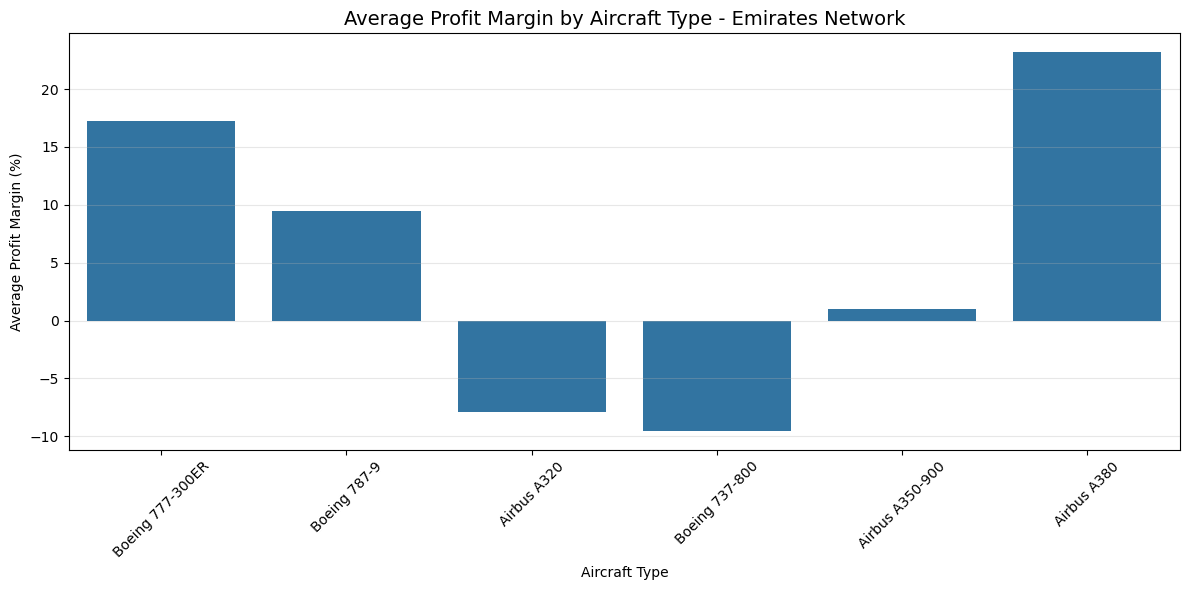

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=routes_enriched, x='Aircraft_Type', y='Profit_Margin', errorbar=None)
plt.title('Average Profit Margin by Aircraft Type - Emirates Network', fontsize=14)
plt.xlabel('Aircraft Type')
plt.ylabel('Average Profit Margin (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

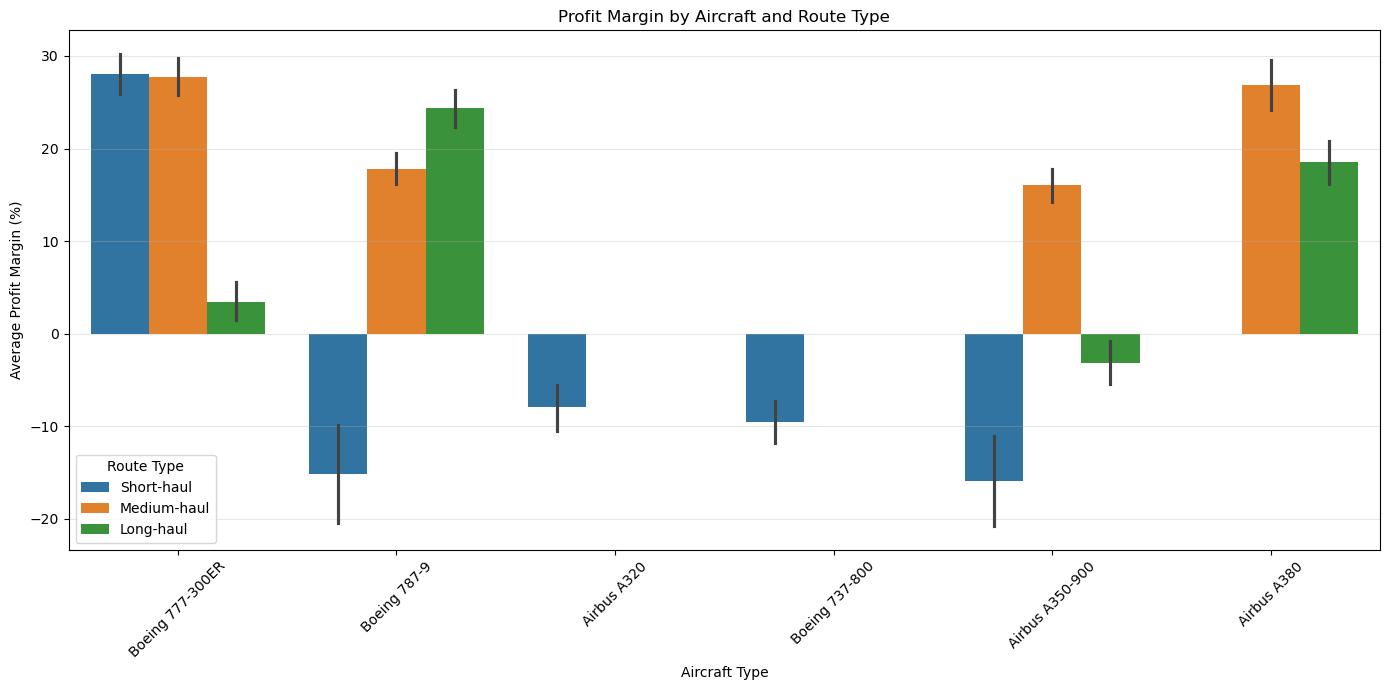

In [11]:
plt.figure(figsize=(14, 7))
sns.barplot(data=routes_enriched, x='Aircraft_Type', y='Profit_Margin', hue='route_type')
plt.title('Profit Margin by Aircraft and Route Type')
plt.xlabel('Aircraft Type')
plt.ylabel('Average Profit Margin (%)')
plt.xticks(rotation=45)
plt.legend(title='Route Type')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

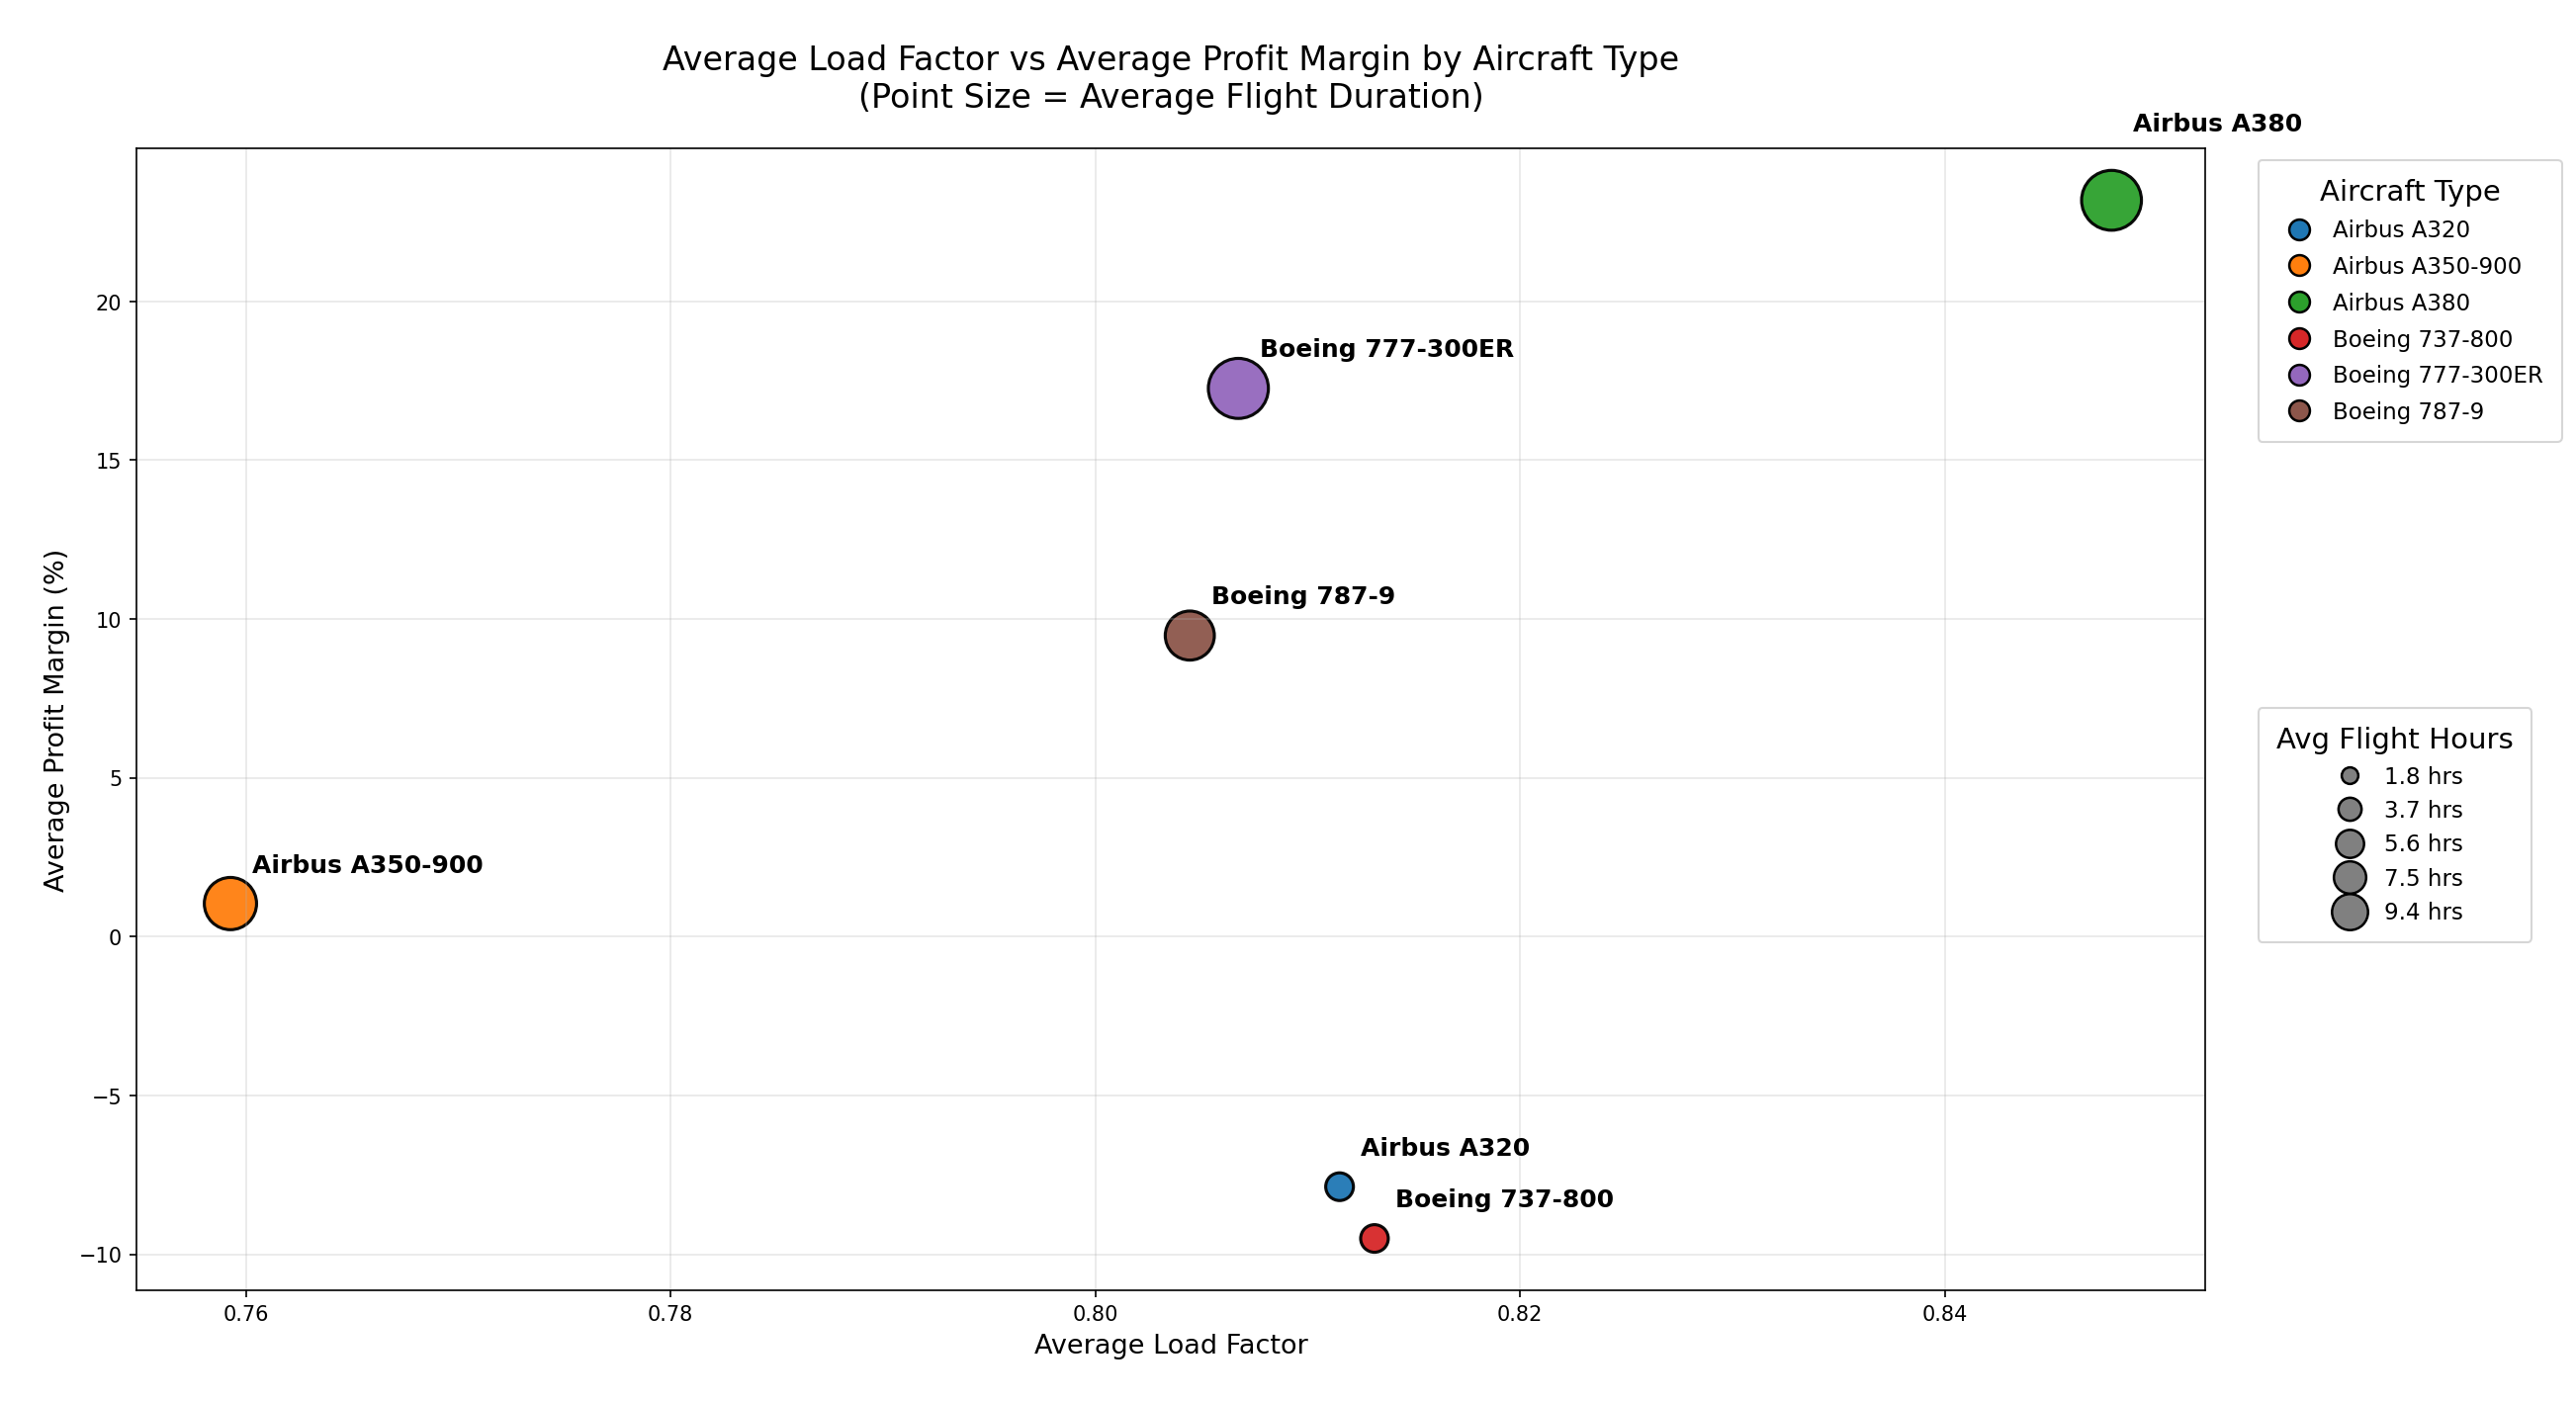

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from IPython.display import display, Image
import numpy as np

# Chiudi tutti i plot precedenti per evitare duplicati
plt.close('all')

agg_data = routes_enriched.groupby('Aircraft_Type').agg({
    'Load_Factor': 'mean',
    'Profit_Margin': 'mean',
    'flight_hours': 'mean'
}).reset_index()

fig, ax = plt.subplots(figsize=(18, 10))

sns.scatterplot(
    data=agg_data,
    x='Load_Factor',
    y='Profit_Margin', 
    hue='Aircraft_Type',
    size='flight_hours',
    sizes=(180, 850),
    alpha=0.95,
    edgecolor='black',
    linewidth=1.5,
    ax=ax
)

ax.set_title('Average Load Factor vs Average Profit Margin by Aircraft Type\n(Point Size = Average Flight Duration)', fontsize=16, pad=20)
ax.set_xlabel('Average Load Factor', fontsize=13)
ax.set_ylabel('Average Profit Margin (%)', fontsize=13)

# Aircraft labels
for i, row in agg_data.iterrows():
    offset = 2.2 if row['Aircraft_Type'] == 'Airbus A380' else 1.0
    ax.text(row['Load_Factor'] + 0.001, row['Profit_Margin'] + offset, 
             row['Aircraft_Type'], fontsize=12, fontweight='bold')

# Rimuovi la legenda automatica di seaborn
ax.get_legend().remove()

palette = sns.color_palette()
aircraft_types = agg_data['Aircraft_Type'].tolist()

# --- Legenda 1: Aircraft Type (colori) ---
color_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[i],
           markersize=10, markeredgecolor='black', markeredgewidth=1.2)
    for i in range(len(aircraft_types))
]
legend1 = ax.legend(
    handles=color_handles,
    labels=aircraft_types,
    title='Aircraft Type',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=11,
    title_fontsize=14,
    frameon=True,
    borderpad=0.8,
    labelspacing=0.6,
    handletextpad=0.5,
)
ax.add_artist(legend1)

# --- Legenda 2: Avg Flight Hours (dimensioni) ---
min_hours = agg_data['flight_hours'].min()
max_hours = agg_data['flight_hours'].max()
hour_values = np.linspace(min_hours, max_hours, 5)

def scale_size(val, vmin, vmax, smin=180, smax=850):
    return smin + (val - vmin) / (vmax - vmin) * (smax - smin)

size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=np.sqrt(scale_size(h, min_hours, max_hours)) * 0.6,
           markeredgecolor='black', markeredgewidth=1.2)
    for h in hour_values
]
size_labels = [f'{h:.1f} hrs' for h in hour_values]

legend2 = ax.legend(
    handles=size_handles,
    labels=size_labels,
    title='Avg Flight Hours',
    bbox_to_anchor=(1.02, 0.52),
    loc='upper left',
    fontsize=11,
    title_fontsize=14,
    frameon=True,
    borderpad=0.8,
    labelspacing=0.5,
    handletextpad=0.5,
)

ax.grid(True, alpha=0.3)

# Salva e mostra — NON usare plt.show()
fig.savefig('/tmp/plot_tmp.png', bbox_inches='tight', dpi=150, pad_inches=0.3)
plt.close(fig)  # chiude la figura per evitare il doppio render
display(Image('/tmp/plot_tmp.png'))